# 05 - Statistical inference with prepared swim data


# Common setup

These notebooks assume a local project structure like:

```text
project/
  data/
    workouts.csv
    samples.csv              # optional
    intervals.csv            # optional
    race_results.csv          # optional
```

The exact iOS export format may vary. The helper functions below try to standardize common column names. If your export uses different names, edit the `COLUMN_ALIASES` dictionary.

The notebooks also include a small synthetic-data fallback. That lets the notebook run even before real Apple Watch / iOS CSV files are placed in `data/`.

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


In [1]:
from pathlib import Path
import math
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

clean_path = PROCESSED_DIR / "clean_workouts.csv"
weekly_path = PROCESSED_DIR / "weekly_training.csv"

if not clean_path.exists() or not weekly_path.exists():
    raise FileNotFoundError("Run 01_swim_data_ingestion_and_cleaning.ipynb first to create prepared swim data.")

workouts = pd.read_csv(clean_path)
weekly = pd.read_csv(weekly_path)

workouts["date"] = pd.to_datetime(workouts["date"], errors="coerce", utc=True).dt.tz_convert(None)
if "week_start" in workouts.columns:
    workouts["week_start"] = pd.to_datetime(workouts["week_start"], errors="coerce", utc=True).dt.tz_convert(None)
else:
    workouts["week_start"] = workouts["date"].dt.to_period("W").dt.start_time

weekly["week_start"] = pd.to_datetime(weekly["week_start"], errors="coerce", utc=True).dt.tz_convert(None)
weekly = weekly.dropna(subset=["week_start", "avg_pace_sec_per_100m"]).sort_values("week_start").reset_index(drop=True)
weekly["week_index"] = (weekly["week_start"] - weekly["week_start"].min()).dt.days / 7
weekly["cumulative_distance_m"] = weekly["total_distance_m"].fillna(0).cumsum()

workouts = workouts.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
workouts["season_half"] = np.where(workouts["date"] < workouts["date"].median(), "First half", "Second half")

print("Loaded prepared workouts:", len(workouts))
print("Loaded prepared weekly rows:", len(weekly))
display(weekly.head(3))
display(weekly.tail(3))


Loaded prepared workouts: 452
Loaded prepared weekly rows: 104


,week_start,sessions,total_distance_m,avg_distance_m,avg_pace_sec_per_100m,median_pace_sec_per_100m,avg_hr,avg_distance_per_stroke_m,avg_swolf,week_index,cumulative_distance_m
0,2024-05-27,2,4686.300125,2343.150063,140.445602,140.445602,NaN,2.296495,NaN,0.0,4686.300125
1,2024-06-03,4,11978.640320,2994.660080,94.599379,94.450755,NaN,2.881921,NaN,1.0,16664.940445
2,2024-06-10,6,22821.800079,3803.633347,115.768771,79.489092,NaN,2.696377,NaN,2.0,39486.740524


,week_start,sessions,total_distance_m,avg_distance_m,avg_pace_sec_per_100m,median_pace_sec_per_100m,avg_hr,avg_distance_per_stroke_m,avg_swolf,week_index,cumulative_distance_m
101,2026-06-01,8,23565.900345,2945.737543,136.489127,132.297215,NaN,2.647709,NaN,105.0,1.448233e+06
102,2026-06-08,4,14934.640076,3733.660019,116.752654,117.050274,NaN,2.977347,NaN,106.0,1.463168e+06
103,2026-06-15,4,15888.920074,3972.230019,118.164580,117.288954,NaN,2.922873,NaN,107.0,1.479057e+06


## Descriptive statistics

Start with center, spread, and shape. Lower pace values mean faster swimming.

Mean pace:

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

Code-style implementation:

```python
mean_pace=("pace_sec_per_100m", "mean")
```

Standard deviation:

$$
s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n - 1}}
$$

Code-style implementation:

```python
sd_pace=("pace_sec_per_100m", "std")
```

**Expected output:** Expect grouped summaries rather than individual records. Compare groups to find patterns by week, event, stroke, phase, or other categories.


In [2]:
summary = workouts.groupby("season_half").agg(
    n=("pace_sec_per_100m", "count"),
    mean_pace=("pace_sec_per_100m", "mean"),
    median_pace=("pace_sec_per_100m", "median"),
    sd_pace=("pace_sec_per_100m", "std"),
    q1=("pace_sec_per_100m", lambda s: s.quantile(.25)),
    q3=("pace_sec_per_100m", lambda s: s.quantile(.75)),
    mean_distance=("distance_m", "mean")
)
summary["iqr_pace"] = summary["q3"] - summary["q1"]
summary

,n,mean_pace,median_pace,sd_pace,q1,q3,mean_distance,iqr_pace
season_half,,,,,,,,
First half,226,102.437733,96.263042,25.268054,88.713178,106.723927,3436.653262,18.010749
Second half,226,109.212076,101.878954,25.311750,93.496386,120.078416,3107.845994,26.582030


## Distribution visualizations

Histograms and boxplots help identify skew, outliers, and changes in spread.

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


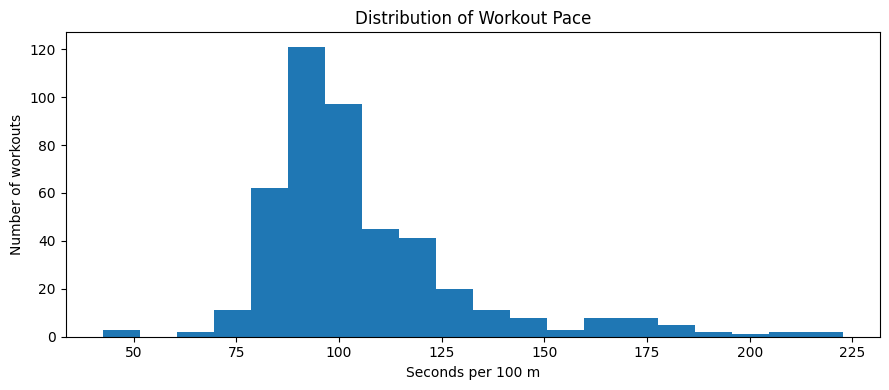

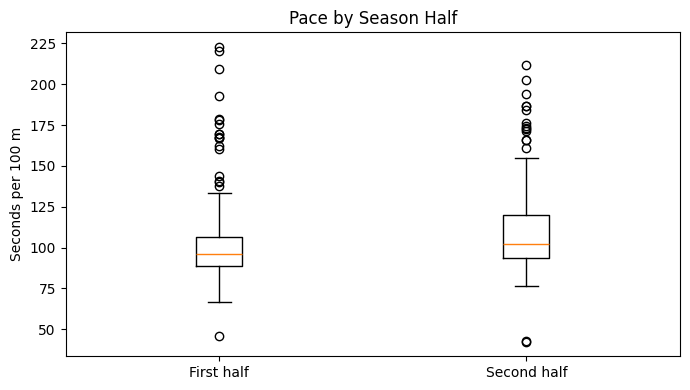

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.hist(workouts["pace_sec_per_100m"].dropna(), bins=20)
plt.title("Distribution of Workout Pace")
plt.xlabel("Seconds per 100 m")
plt.ylabel("Number of workouts")
plt.tight_layout()
plt.show()

data = [g["pace_sec_per_100m"].dropna().values for _, g in workouts.groupby("season_half")]
labels = [name for name, _ in workouts.groupby("season_half")]
plt.figure(figsize=(7, 4))
plt.boxplot(data, labels=labels)
plt.title("Pace by Season Half")
plt.ylabel("Seconds per 100 m")
plt.tight_layout()
plt.show()

## Confidence interval for recent mean pace

For a sample mean, a t-interval is:

$$
\bar{x} \pm t^*\frac{s}{\sqrt{n}}
$$

Code-style implementation:

```python
se = sd / math.sqrt(n)
ci = (mean - t_star * se, mean + t_star * se)
```

This estimates the true mean pace for workouts similar to the recent sample.

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


In [4]:
from scipy import stats

recent = workouts.sort_values("date").tail(min(30, len(workouts)))["pace_sec_per_100m"].dropna()
n = len(recent)
mean = recent.mean()
sd = recent.std(ddof=1)
se = sd / math.sqrt(n)
t_star = stats.t.ppf(.975, df=n-1)
ci = (mean - t_star*se, mean + t_star*se)

print(f"n = {n}")
print(f"Recent mean pace = {mean:.2f} sec/100m")
print(f"95% CI = ({ci[0]:.2f}, {ci[1]:.2f}) sec/100m")

n = 30
Recent mean pace = 120.43 sec/100m
95% CI = (107.80, 133.05) sec/100m


## Hypothesis test: early vs late season

A possible research question:

> Is the swimmer faster in the second half of the year than in the first half?

Since lower pace is faster:

$$
H_0: \mu_{second} = \mu_{first}
$$

$$
H_a: \mu_{second} < \mu_{first}
$$

Code-style implementation:

```python
test = stats.ttest_ind(second, first, equal_var=False, alternative="less")
```

The alternative is `less` because a smaller pace means a faster swim.

**Expected output:** Expect new derived variables, cleaned columns, or summary objects. Check that the resulting values match the formula and intended units.


In [5]:
first = workouts.loc[workouts["season_half"] == "First half", "pace_sec_per_100m"].dropna()
second = workouts.loc[workouts["season_half"] == "Second half", "pace_sec_per_100m"].dropna()

test = stats.ttest_ind(second, first, equal_var=False, alternative="less")

print(f"First-half mean:  {first.mean():.2f} sec/100m, n={len(first)}")
print(f"Second-half mean: {second.mean():.2f} sec/100m, n={len(second)}")
print(f"Difference second - first: {second.mean() - first.mean():.2f} sec/100m")
print(f"t statistic: {test.statistic:.3f}")
print(f"p-value: {test.pvalue:.4f}")

First-half mean:  102.44 sec/100m, n=226
Second-half mean: 109.21 sec/100m, n=226
Difference second - first: 6.77 sec/100m
t statistic: 2.847
p-value: 0.9977


## Regression: weekly volume and pace

Regression asks whether weeks with higher volume tend to have faster average pace.

Model:

$$
\widehat{\text{pace}} = a + b(\text{weekly volume})
$$

Code-style implementation:

```python
lm = LinearRegression().fit(X, y)
reg["pred"] = lm.predict(X)
```

Correlation for the same two variables:

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{(n - 1)s_xs_y}
$$

Code-style implementation:

```python
r = np.corrcoef(reg["total_distance_m"], reg["avg_pace_sec_per_100m"])[0, 1]
```

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


Correlation r: -0.231
Regression: pace = 114.943 + -0.000626 * weekly_volume_m
R²: 0.053


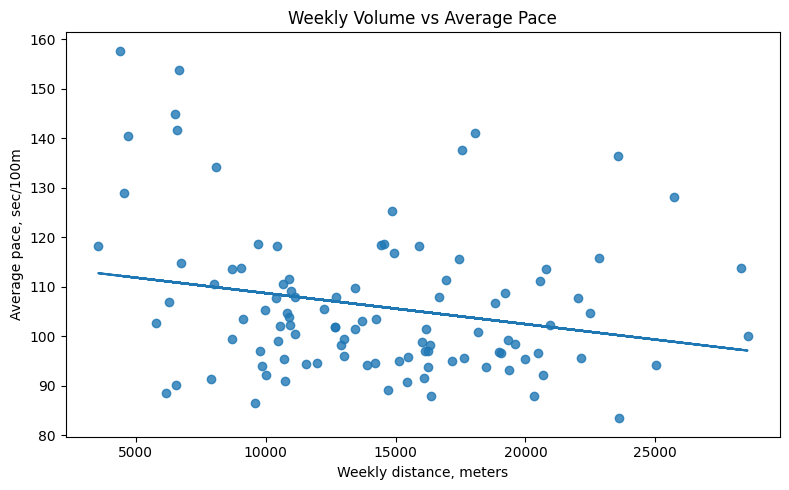

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

reg = weekly.dropna(subset=["total_distance_m", "avg_pace_sec_per_100m"]).copy()
X = reg[["total_distance_m"]].values
y = reg["avg_pace_sec_per_100m"].values

lm = LinearRegression().fit(X, y)
reg["pred"] = lm.predict(X)
reg["resid"] = y - reg["pred"]

r = np.corrcoef(reg["total_distance_m"], reg["avg_pace_sec_per_100m"])[0, 1]

print(f"Correlation r: {r:.3f}")
print(f"Regression: pace = {lm.intercept_:.3f} + {lm.coef_[0]:.6f} * weekly_volume_m")
print(f"R²: {r2_score(y, reg['pred']):.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(reg["total_distance_m"], reg["avg_pace_sec_per_100m"], alpha=.8)
plt.plot(reg["total_distance_m"], reg["pred"])
plt.title("Weekly Volume vs Average Pace")
plt.xlabel("Weekly distance, meters")
plt.ylabel("Average pace, sec/100m")
plt.tight_layout()
plt.show()

## Residual plot

A regression residual is the difference between the observed value and the predicted value:

$$
\text{residual}_i = y_i - \hat{y}_i
$$

Code-style implementation:

```python
reg["resid"] = y - reg["pred"]
```

Residuals should not show a strong curve or funnel pattern if a simple linear model is appropriate.

**Expected output:** Expect a visual display of the data. Look for trends, clusters, outliers, and places where the graph raises a new question.


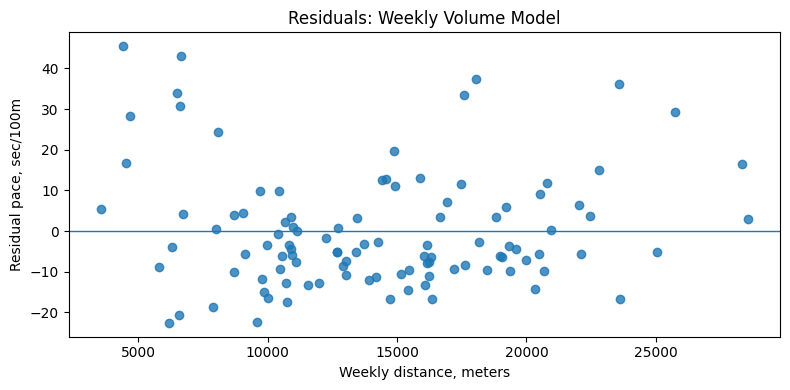

In [7]:
plt.figure(figsize=(8, 4))
plt.axhline(0, linewidth=1)
plt.scatter(reg["total_distance_m"], reg["resid"], alpha=.8)
plt.title("Residuals: Weekly Volume Model")
plt.xlabel("Weekly distance, meters")
plt.ylabel("Residual pace, sec/100m")
plt.tight_layout()
plt.show()

## Randomization test idea

A randomization test can ask:

> If there were no real difference between early and late workouts, how often would random labels produce a difference this large?

The observed statistic is:

$$
\Delta = \bar{x}_{second} - \bar{x}_{first}
$$

Code-style implementation:

```python
observed = second.mean() - first.mean()
```

The simulation repeatedly shuffles labels, recomputes the difference, and estimates a p-value from the simulated differences.

**Expected output:** Expect a visual display of the data. Look for trends, clusters, outliers, and places where the graph raises a new question.


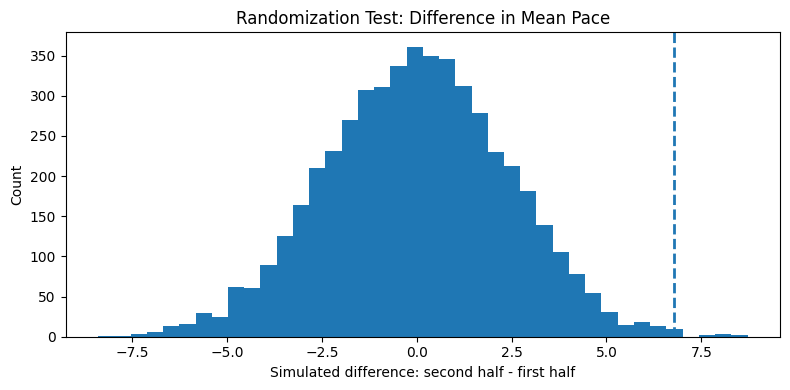

Observed difference: 6.77 sec/100m
Simulation p-value: 0.9980


In [8]:
observed = second.mean() - first.mean()
combined = pd.concat([first, second]).values
n_second = len(second)

rng = np.random.default_rng(42)
simulated = []
for _ in range(5000):
    shuffled = rng.permutation(combined)
    sim_second = shuffled[:n_second]
    sim_first = shuffled[n_second:]
    simulated.append(sim_second.mean() - sim_first.mean())

simulated = np.array(simulated)
p_sim = np.mean(simulated <= observed)

plt.figure(figsize=(8, 4))
plt.hist(simulated, bins=40)
plt.axvline(observed, linestyle="--", linewidth=2)
plt.title("Randomization Test: Difference in Mean Pace")
plt.xlabel("Simulated difference: second half - first half")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Observed difference: {observed:.2f} sec/100m")
print(f"Simulation p-value: {p_sim:.4f}")